# Week 11 - Introduction to Modeling, part 2

# 1. Lesson - No lesson this week

# 2. Weekly graph question

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

The book names one of Vonnegut's rules as "keep it simple" and another as "have the guts to cut."  Here is some data from the previous week's lesson.  If you had to cut one of the two plots below, which would it be?  Which seems more interesting or important?  Explain.  (Should "amount of training data used" or "number of estimators" be on the x-axis.)

In [2]:
np.random.seed(0)
num_points = 10000
feature_1a = np.random.random(size = num_points) * 3
feature_2a = np.random.random(size = num_points) * 3
feature_3a = np.random.random(size = num_points) * 3
train_target = (feature_1a - 2 * feature_2a) * feature_3a + np.random.normal(size = num_points)
feature_1b = np.random.random(size = num_points) * 3
feature_2b = np.random.random(size = num_points) * 3
feature_3b = np.random.random(size = num_points) * 3
test_target = (feature_1b - 2 * feature_2b) * feature_3b + np.random.normal(size = num_points)
train_df = pd.DataFrame({"f1": feature_1a, "f2": feature_2a, "f3": feature_3a})
test_df = pd.DataFrame({"f1": feature_1b, "f2": feature_2b, "f3": feature_3b})
rf = RandomForestRegressor()
rf.fit(train_df.values, train_target)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
rmse_lst = list()
rf = RandomForestRegressor()
for x in range(round(num_points / 20), num_points, round(num_points / 20)):
    rf.fit(train_df.values[0:x,:], train_target[0:x])
    rmse_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

Text(0, 0.5, 'Loss function')

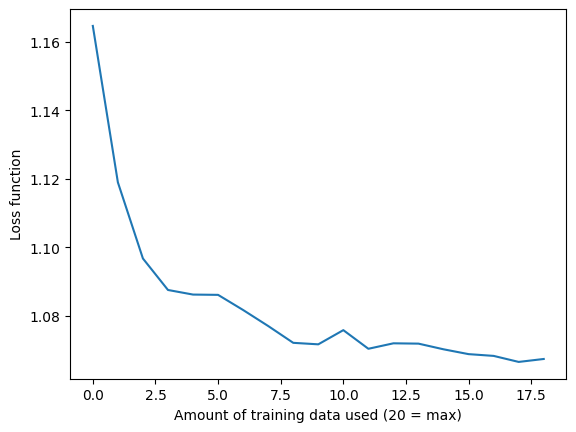

In [4]:
plt.plot(rmse_lst)
plt.xlabel("Amount of training data used (20 = max)")
plt.ylabel("Loss function")

In [5]:
num_trees_lst = list()
for n_estimators in range(1, 100, 3):
    rf = RandomForestRegressor(n_estimators = n_estimators)
    rf.fit(train_df.values, train_target)
    num_trees_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

Text(0, 0.5, 'Loss function')

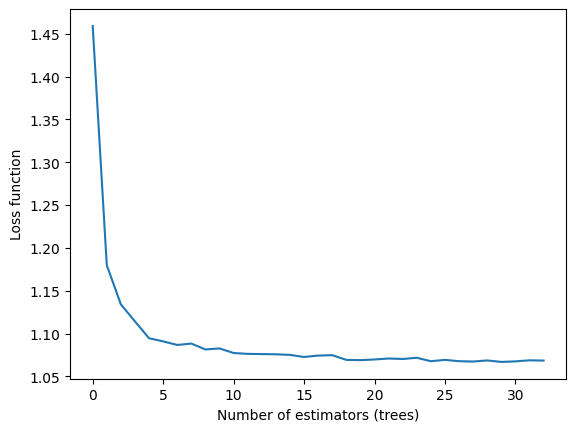

In [6]:
plt.plot(num_trees_lst)
plt.xlabel("Number of estimators (trees)")
plt.ylabel("Loss function")

The first graph should be cut because the x-axis is more difficult to interpret. Why does 20 = max amount of data? Is it percent? Is it number of samples? It is unclear when just looking at the visual graph. In comparison, the second graph is much more readable because you can see how the loss function is reduced by the number of estimators for the model.

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:

* Implement a random forest model.
* Perform cross-validation.
* Tune hyperparameters.
* Evaluate a performance metric.

If you like, you can try other types of models, too (beyond linear regression and random forest) although you will have many opportunities to do that next semester.

In [2]:
from sklearn.model_selection import train_test_split, cross_validate, RepeatedKFold, KFold, cross_val_score
from sklearn.ensemble import RandomForestRegressor

from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [3]:
cancer_rates = pd.read_csv("..\Projects\Health Disparities Analytics\Processed Data\(COMBINED) Cancer Rates.csv")
cancer_deaths = pd.read_csv("..\Projects\Health Disparities Analytics\Processed Data\(COMBINED) cancer_deaths.csv")
census_pop = pd.read_csv("..\Projects\Health Disparities Analytics\Processed Data\(IMPUTED) census_pop_county.csv")
house_income = pd.read_csv("..\Projects\Health Disparities Analytics\Processed Data\(IMPUTED) RESHAPED Unemployment and median household income.csv")
life_expect_kff = pd.read_csv("..\Projects\Health Disparities Analytics\Processed Data\KFF - life expectancy at birth by race.csv")
life_expect_nchs = pd.read_csv(r"..\Projects\Health Disparities Analytics\Processed Data\NCHS_-_Death_rates_and_life_expectancy_at_birth.csv")

pd.set_option('display.max_columns', None)

In [4]:
# Define Function for Backward Feature Selection

def backward_feature_selection(X, y, model,
                               scoring = 'neg_mean_absolute_error',
                               cv = 5,
                               tol = 1e-4,             # None = no delta cutoff
                                                       # use 0.0 for "no further improvements"
                                                       # and 1e-4 for "point of diminishing returns"
                               max_features = None,    # If None, remove features until only 1 remains
                                                       # Otherwise, stop when this many features remain
                               n_jobs = -1,
                               verbose = True
                              ):

    # Helper function to compute CV score
    def cv_score(features):
        return -cross_val_score(model, X[features], y,
                                scoring = scoring, cv = cv,
                                n_jobs = n_jobs).mean()

    # Start with all features (using a list for easier manipulation)
    features_remaining = list(X.columns)

    # Compute initial CV score with the full feature set
    initial_score = cv_score(features_remaining)

    # Initialize tracking variables
    best_score        = initial_score                # Best (lowest) CV score observed so far
    best_feature_set  = features_remaining.copy()    # Feature set corresponding to best_score
    selected_features = ['NONE']                     # List to record the order in which features are removed
    best_scores       = [initial_score]              # List to record the CV score after each removal (starting with full set)

    if verbose:
        print("Start with full set of features:")
        print(f'{features_remaining}  CV score (MAE): {np.around(initial_score, 4)}\n')

    # Determine the target number of features to keep:
    # For backward elimination, if max_features is None, we remove until 1 feature remains.
    target_feature_count = 1 if max_features is None else max_features

    prev_score = initial_score
    round_num = 1
    # Continue removing features until we reach the target count
    while len(features_remaining) > target_feature_count:
        if verbose:
            print(f'Round {round_num}:')

        # Initialize variables to track the best removal in this round
        lowest_score = float('inf')
        feature_to_remove = None
        best_new_features = None

        # Try removing each feature one at a time
        for feature in features_remaining:
            new_feature_set = features_remaining.copy()
            new_feature_set.remove(feature)
            new_score = cv_score(new_feature_set)
            if verbose:
                print('Trying removal of:',feature, np.around(new_score, 4))
            if new_score < lowest_score:
                lowest_score = new_score
                feature_to_remove = feature
                best_new_features = new_feature_set

        # Check if improvement is significant enough (if tol is set)
        if tol is not None and (prev_score - lowest_score) < tol:
            if verbose:
                print("\nStopping early due to minimal improvement.")
            break

        # Update the best score and feature set if current removal improves performance
        if lowest_score < best_score:
            best_score = lowest_score
            best_feature_set = best_new_features.copy()

        # Update trackers for this round
        prev_score = lowest_score
        features_remaining = best_new_features
        selected_features.append(feature_to_remove)
        best_scores.append(lowest_score)

        if verbose:
            print(f'\nRemoving {feature_to_remove}:  CV score (MAE) {np.around(lowest_score, 4)}\n')
        round_num += 1

    return (
        selected_features,      # Order in which features were removed
        best_scores,            # CV scores after each removal step
        best_feature_set,       # Feature set that achieved the best CV score
        best_score              # Best (lowest) CV score
    )

#### ^ Backwards Feature Selection method credit: Professor Wayne Snyder

In [5]:
cancer_death_cat_cols = cancer_deaths[cancer_deaths.columns].select_dtypes(exclude="number")
cancer_death_cat_cols

,SEX,SEX_CODED,RACE,ETHNIC_GROUP,MARITAL_STATUS,MARITAL_STATUS_CODED,EDUCATION,RESIDENT_STATUS,CAUSE_OF_DEATH,PLACE_OF_DEATH,AUTOPSY
0,Male,M,White,Non-Hispanic White,Divorced,D,Bachelors Degree,Resident,Malignant neoplasm of prostate (C61),Nursing home,N
1,Female,F,White,Non-Hispanic White,Widowed,W,Some College,Resident,"Malignant neoplasms of colon, rectum and anus ...",Home,N
2,Female,F,White,Non-Hispanic White,Divorced,D,Some College,Resident,Malignant neoplasm of pancreas (C25),Home,N
3,Female,F,White,Non-Hispanic White,Widowed,W,HS Grad / GED,Resident,"Malignant neoplasms of trachea, bronchus and l...",Home,N
4,Female,F,White,Non-Hispanic White,Divorced,D,HS Grad / GED,Resident,"Malignant neoplasms of trachea, bronchus and l...",Home,N
...,...,...,...,...,...,...,...,...,...,...,...
1578484,Female,F,Asian,Chinese,Married,M,HS Grad / GED,Resident,Leukemia (C91-C95),Hospital (Inpatient),N
1578485,Female,F,Black,Non-Hispanic Black,Never Married,S,Less than HS,Resident,"Malignant neoplasms of meninges, brain and oth...",Home,N
1578486,Male,M,Black,Non-Hispanic Black,Divorced,D,HS Grad / GED,Resident,Leukemia (C91-C95),Hospital (Inpatient),N
1578487,Male,M,AIAN,American Indian or Alaskan Native (AIAN),Married,M,Bachelors Degree,Intrastate Non-resident,"Malignant neoplasms of colon, rectum and anus ...",Hospital (Inpatient),N


In [6]:
cancer_death_cat_cols_list = cancer_death_cat_cols.columns.tolist()

In [49]:
cancer_deaths_encoded = pd.get_dummies(cancer_deaths, columns=cancer_death_cat_cols_list, drop_first=True)

encoder = OneHotEncoder(sparse_output=False)
one_hot_encoded = encoder.fit_transform(cancer_deaths[cancer_death_cat_cols_list])
one_hot_df = pd.DataFrame(one_hot_encoded, columns=encoder.get_feature_names_out(cancer_death_cat_cols_list), index=cancer_deaths.index)
df_sklearn_encoded = pd.concat([cancer_deaths.drop(cancer_death_cat_cols_list, axis=1), one_hot_df], axis=1)

print(f"One-Hot Encoded Data using Scikit-Learn:\n{df_sklearn_encoded}\n")

One-Hot Encoded Data using Scikit-Learn:
          AGE  HISPANIC_CODED  EDUCATION_CODED  RESIDENT_STATUS_CODED  \
0        93.0               6               61                      1   
1        61.0               6               51                      1   
2        63.0               6               41                      1   
3        67.0               6               31                      1   
4        76.0               6               31                      1   
...       ...             ...              ...                    ...   
1578484  55.0               8               31                      1   
1578485  71.0               7               11                      1   
1578486  73.0               7               31                      1   
1578487  54.0               8               61                      2   
1578488  70.0               4               51                      1   

         CAUSE_RECODE_113  MANNER_OF_DEATH  MANNER_OF_DEATH_CODED  \
0            

In [50]:
cancer_deaths_OHE = cancer_deaths_encoded.copy()
cancer_deaths_OHE.head()

,AGE,HISPANIC_CODED,EDUCATION_CODED,RESIDENT_STATUS_CODED,CAUSE_RECODE_113,MANNER_OF_DEATH,MANNER_OF_DEATH_CODED,PLACE_OF_DEATH_CODED,DATA_YEAR,MONTH_OF_DEATH,WEEKDAY_OF_DEATH,SEX_Male,SEX_CODED_M,RACE_Asian,RACE_Black,RACE_Hispanic,RACE_Multiracial,RACE_NHOPI,RACE_White,ETHNIC_GROUP_AIAN and NHOPI,ETHNIC_GROUP_AIAN and White,"ETHNIC_GROUP_AIAN, Asian and NHOPI","ETHNIC_GROUP_AIAN, Asian and White","ETHNIC_GROUP_AIAN, Asian, NHOPI and White","ETHNIC_GROUP_AIAN, NHOPI and White",ETHNIC_GROUP_American Indian or Alaskan Native (AIAN),ETHNIC_GROUP_Asian Indian,ETHNIC_GROUP_Asian and NHOPI,ETHNIC_GROUP_Asian and White,"ETHNIC_GROUP_Asian, NHOPI and White",ETHNIC_GROUP_Black and AIAN,ETHNIC_GROUP_Black and Asian,ETHNIC_GROUP_Black and Native Hawaiian or Other Pacific Islander (NHOPI),ETHNIC_GROUP_Black and White,"ETHNIC_GROUP_Black, AIAN and Asian","ETHNIC_GROUP_Black, AIAN and NHOPI","ETHNIC_GROUP_Black, AIAN and White","ETHNIC_GROUP_Black, AIAN, Asian and White","ETHNIC_GROUP_Black, Asian and NHOPI","ETHNIC_GROUP_Black, Asian and White","ETHNIC_GROUP_Black, Asian, NHOPI and White","ETHNIC_GROUP_Black, NHOPI and White",ETHNIC_GROUP_Central or South American,ETHNIC_GROUP_Chinese,ETHNIC_GROUP_Cuban,ETHNIC_GROUP_Filipino,ETHNIC_GROUP_Guamanian,ETHNIC_GROUP_Hawaiian,ETHNIC_GROUP_Japanese,ETHNIC_GROUP_Korean,ETHNIC_GROUP_Mexican,ETHNIC_GROUP_NHOPI and White,ETHNIC_GROUP_Non-Hispanic Black,ETHNIC_GROUP_Non-Hispanic White,ETHNIC_GROUP_Other or Multiple Asian,ETHNIC_GROUP_Other or Multiple Pacific Islander,ETHNIC_GROUP_Other/Unknown Hispanic,ETHNIC_GROUP_Puerto Rican,ETHNIC_GROUP_Samoan,ETHNIC_GROUP_Vietnamese,MARITAL_STATUS_Married,MARITAL_STATUS_Never Married,MARITAL_STATUS_Unknown,MARITAL_STATUS_Widowed,MARITAL_STATUS_CODED_M,MARITAL_STATUS_CODED_S,MARITAL_STATUS_CODED_U,MARITAL_STATUS_CODED_W,EDUCATION_Bachelors Degree,EDUCATION_HS Grad / GED,EDUCATION_Less than HS,EDUCATION_Some College,EDUCATION_Unknown,RESIDENT_STATUS_Interstate Non-resident,RESIDENT_STATUS_Intrastate Non-resident,RESIDENT_STATUS_Resident,CAUSE_OF_DEATH_Malignant melanoma of skin (C43),CAUSE_OF_DEATH_Malignant neoplasm of bladder (C67),CAUSE_OF_DEATH_Malignant neoplasm of breast (C50),CAUSE_OF_DEATH_Malignant neoplasm of cervix uteri (C53),CAUSE_OF_DEATH_Malignant neoplasm of esophagus (C15),CAUSE_OF_DEATH_Malignant neoplasm of larynx (C32),CAUSE_OF_DEATH_Malignant neoplasm of ovary (C56),CAUSE_OF_DEATH_Malignant neoplasm of pancreas (C25),CAUSE_OF_DEATH_Malignant neoplasm of prostate (C61),CAUSE_OF_DEATH_Malignant neoplasm of stomach (C16),"CAUSE_OF_DEATH_Malignant neoplasms of colon, rectum and anus (C18-C21)","CAUSE_OF_DEATH_Malignant neoplasms of corpus uteri and uterus, part unspecified (C54-C55)",CAUSE_OF_DEATH_Malignant neoplasms of kidney and renal pelvis (C64-C65),"CAUSE_OF_DEATH_Malignant neoplasms of lip, oral cavity and pharynx (C00-C14)",CAUSE_OF_DEATH_Malignant neoplasms of liver and intrahepatic bile ducts (C22),"CAUSE_OF_DEATH_Malignant neoplasms of meninges, brain and other parts of central nervous system (C70-C72)","CAUSE_OF_DEATH_Malignant neoplasms of trachea, bronchus and lung (C33-C34)","CAUSE_OF_DEATH_Multiple myeloma and immunoproliferative neoplasms (C88, C90)",CAUSE_OF_DEATH_Non-Hodgkin lymphoma (C82-C85),CAUSE_OF_DEATH_Other and unspecified malignant neoplasms,PLACE_OF_DEATH_Hospice,PLACE_OF_DEATH_Hospital (Dead on Arrival),PLACE_OF_DEATH_Hospital (Inpatient),PLACE_OF_DEATH_Hospital (Outpatient/ER),PLACE_OF_DEATH_Nursing home,PLACE_OF_DEATH_Other,PLACE_OF_DEATH_Unknown,AUTOPSY_U,AUTOPSY_Y,AUTOPSY_n
0,93.0,6,61,1,33,NaN,7.0,6,2018,1,3,True,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False

In [51]:
# Combine encoded features with numeric features

numerical_cols = cancer_deaths.columns.difference(cancer_death_cat_cols_list)

df_numeric_only = cancer_deaths[numerical_cols].copy()

one_hot_df.index = df_numeric_only.index

cancer_deaths_final = pd.concat([df_numeric_only, cancer_deaths_OHE], axis=1)

cancer_deaths_final = cancer_deaths_final.loc[:, ~cancer_deaths_final.columns.duplicated()]

cancer_deaths_final.to_csv("..\Projects\Health Disparities Analytics\Processed Data\cancer_deaths_encoded.csv", index=False)


In [7]:
# Global CV KFold

random_state = 42

cv = KFold(n_splits=5, shuffle=True, random_state=random_state)

##### Cancer Deaths Model Exploration

In [8]:
data = pd.read_csv("..\Projects\Health Disparities Analytics\Processed Data\cancer_deaths_encoded.csv")

num_cols = data.select_dtypes(include='number').columns
cat_cols = data.select_dtypes(exclude='number').columns

# Fill remaining numerical NaN samples with median value to avoid skewing data
data[num_cols] = data[num_cols].fillna(data[num_cols].median())

# Fill remaining categorical NaN samples with mode value 
data[cat_cols] = data[cat_cols].fillna(data[cat_cols].mode().iloc[0])


# Identify Features and Target Variable
X = data.drop(columns=['AGE'])
y = data['AGE']

# Split Data into Train and Test Sets and Standardize
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)

In [54]:
# Random Forest Model - Baseline

forest_model = RandomForestRegressor(random_state=random_state, n_jobs=-1)
forest_scores = cross_validate(forest_model, X_train, y_train, cv=cv, scoring='neg_mean_absolute_error', return_train_score=True)

forest_mean_train_mae = np.mean(-forest_scores['train_score'])
forest_mean_mae = np.mean(-forest_scores['test_score'])
forest_std_mae = np.std(-forest_scores['test_score'])

print(f"Mean Train MAE Score: {forest_mean_train_mae:,.2f} Years")
print(f"Mean CV MAE Score: {forest_mean_mae:,.2f} Years")
print(f"STD CV MAE Score: {forest_std_mae:,.2f} Years")

Mean Train MAE Score: 5.15 Years
Mean CV MAE Score: 9.03 Years
STD CV MAE Score: 0.02 Years


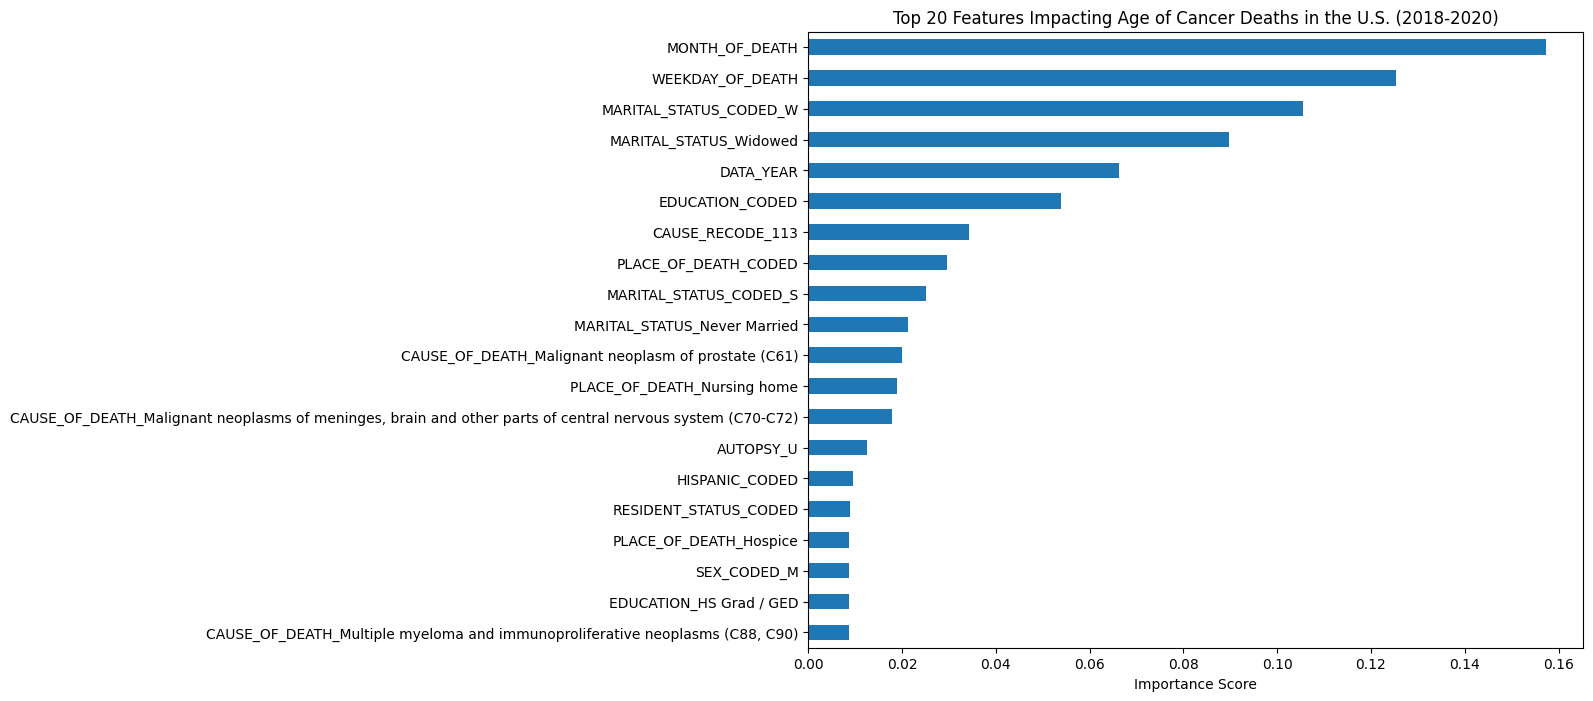

In [55]:
forest_model.fit(X_train, y_train)

important_features = pd.Series(forest_model.feature_importances_, index=X_train.columns)
top_features = important_features.nlargest(20)

top_features.sort_values().plot(kind='barh', figsize=(10, 8))
plt.title("Top 20 Features Impacting Age of Cancer Deaths in the U.S. (2018-2020)")
plt.xlabel("Importance Score")
plt.show()

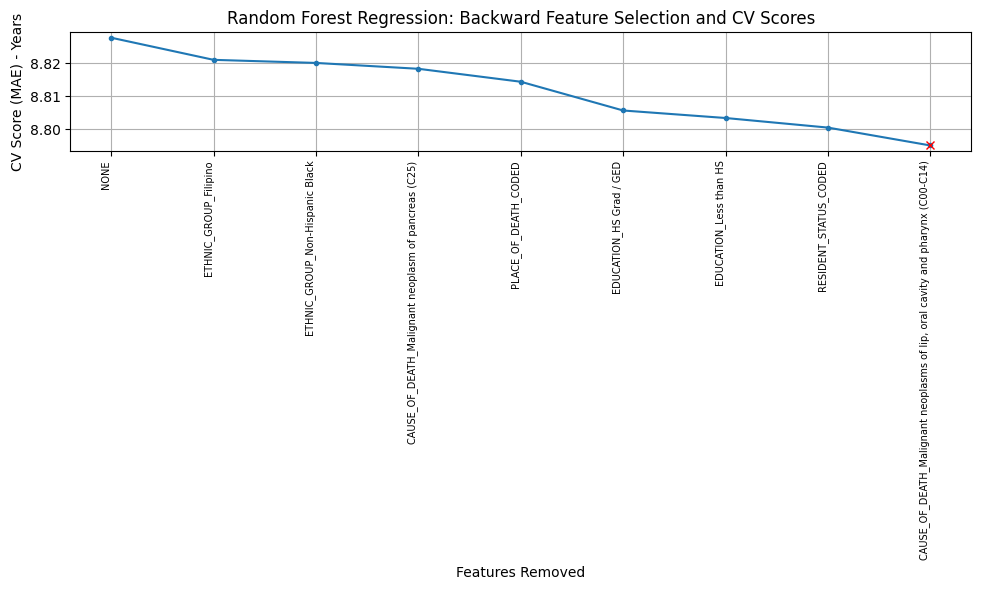

Best feature set: ['CAUSE_RECODE_113', 'DATA_YEAR', 'EDUCATION_CODED', 'HISPANIC_CODED', 'MANNER_OF_DEATH', 'MANNER_OF_DEATH_CODED', 'MONTH_OF_DEATH', 'WEEKDAY_OF_DEATH', 'SEX_Male', 'SEX_CODED_M', 'RACE_Asian', 'RACE_Black', 'RACE_Hispanic', 'RACE_Multiracial', 'RACE_NHOPI', 'RACE_White', 'ETHNIC_GROUP_AIAN and NHOPI', 'ETHNIC_GROUP_AIAN and White', 'ETHNIC_GROUP_AIAN, Asian and NHOPI', 'ETHNIC_GROUP_AIAN, Asian and White', 'ETHNIC_GROUP_AIAN, Asian, NHOPI and White', 'ETHNIC_GROUP_AIAN, NHOPI and White', 'ETHNIC_GROUP_American Indian or Alaskan Native (AIAN)', 'ETHNIC_GROUP_Asian Indian', 'ETHNIC_GROUP_Asian and NHOPI', 'ETHNIC_GROUP_Asian and White', 'ETHNIC_GROUP_Asian, NHOPI and White', 'ETHNIC_GROUP_Black and AIAN', 'ETHNIC_GROUP_Black and Asian', 'ETHNIC_GROUP_Black and Native Hawaiian or Other Pacific Islander (NHOPI)', 'ETHNIC_GROUP_Black and White', 'ETHNIC_GROUP_Black, AIAN and Asian', 'ETHNIC_GROUP_Black, AIAN and NHOPI', 'ETHNIC_GROUP_Black, AIAN and White', 'ETHNIC_GROUP_

In [9]:
# Backward Feature Selection - Random Forest

# shortening the process by allowing a maximum of 25 features out of 100+
model = RandomForestRegressor(random_state=random_state, max_features=25)

# Selecting roughly 20,000 samples due to an insufficient memory space to conduct feature selection on the full dataset (1M+ samples)
X_train_sample = X_train.sample(frac=0.05, random_state=random_state) 
y_train_sample = y_train.loc[X_train_sample.index]

selected_features, best_scores, best_feature_set, best_backward_score = (backward_feature_selection(X_train_sample, y_train_sample, model, cv = 2, verbose = False))

# Plot the results

plt.figure(figsize = (10, 6))
plt.title('Random Forest Regression: Backward Feature Selection and CV Scores')
plt.plot(range(1, len(best_scores) + 1), best_scores, marker = '.')
index = np.argmin(best_scores)
plt.plot([index + 1], best_scores[index], marker = 'x', color = 'red')
plt.xticks(range(1, len(selected_features) + 1), selected_features, rotation = 90, ha = 'right', fontsize = 7)
plt.xlabel('Features Removed')
plt.ylabel('CV Score (MAE) - Years')

plt.grid()
plt.tight_layout()
plt.show()

# Print the best subset and cv score

print("Best feature set:", best_feature_set)
print(f"CV score (MAE): {np.around(best_backward_score, 4)} Years")

In [15]:
cancer_deaths_best_features = ['CAUSE_RECODE_113', 'DATA_YEAR', 'EDUCATION_CODED', 'HISPANIC_CODED', 'MANNER_OF_DEATH', 'MANNER_OF_DEATH_CODED', 'MONTH_OF_DEATH', 'WEEKDAY_OF_DEATH', 'SEX_Male', 'SEX_CODED_M', 'RACE_Asian', 'RACE_Black', 'RACE_Hispanic', 'RACE_Multiracial', 'RACE_NHOPI', 'RACE_White', 'ETHNIC_GROUP_AIAN and NHOPI', 'ETHNIC_GROUP_AIAN and White', 'ETHNIC_GROUP_AIAN, Asian and NHOPI', 'ETHNIC_GROUP_AIAN, Asian and White', 'ETHNIC_GROUP_AIAN, Asian, NHOPI and White', 'ETHNIC_GROUP_AIAN, NHOPI and White', 'ETHNIC_GROUP_American Indian or Alaskan Native (AIAN)', 'ETHNIC_GROUP_Asian Indian', 'ETHNIC_GROUP_Asian and NHOPI', 'ETHNIC_GROUP_Asian and White', 'ETHNIC_GROUP_Asian, NHOPI and White', 'ETHNIC_GROUP_Black and AIAN', 'ETHNIC_GROUP_Black and Asian', 'ETHNIC_GROUP_Black and Native Hawaiian or Other Pacific Islander (NHOPI)', 'ETHNIC_GROUP_Black and White', 'ETHNIC_GROUP_Black, AIAN and Asian', 'ETHNIC_GROUP_Black, AIAN and NHOPI', 'ETHNIC_GROUP_Black, AIAN and White', 'ETHNIC_GROUP_Black, AIAN, Asian and White', 'ETHNIC_GROUP_Black, Asian and NHOPI', 'ETHNIC_GROUP_Black, Asian and White', 'ETHNIC_GROUP_Black, Asian, NHOPI and White', 'ETHNIC_GROUP_Black, NHOPI and White', 'ETHNIC_GROUP_Central or South American', 'ETHNIC_GROUP_Chinese', 'ETHNIC_GROUP_Cuban', 'ETHNIC_GROUP_Guamanian', 'ETHNIC_GROUP_Hawaiian', 'ETHNIC_GROUP_Japanese', 'ETHNIC_GROUP_Korean', 'ETHNIC_GROUP_Mexican', 'ETHNIC_GROUP_NHOPI and White', 'ETHNIC_GROUP_Non-Hispanic White', 'ETHNIC_GROUP_Other or Multiple Asian', 'ETHNIC_GROUP_Other or Multiple Pacific Islander', 'ETHNIC_GROUP_Other/Unknown Hispanic', 'ETHNIC_GROUP_Puerto Rican', 'ETHNIC_GROUP_Samoan', 'ETHNIC_GROUP_Vietnamese', 'MARITAL_STATUS_Married', 'MARITAL_STATUS_Never Married', 'MARITAL_STATUS_Unknown', 'MARITAL_STATUS_Widowed', 'MARITAL_STATUS_CODED_M', 'MARITAL_STATUS_CODED_S', 'MARITAL_STATUS_CODED_U', 'MARITAL_STATUS_CODED_W', 'EDUCATION_Bachelors Degree', 'EDUCATION_Some College', 'EDUCATION_Unknown', 'RESIDENT_STATUS_Interstate Non-resident', 'RESIDENT_STATUS_Intrastate Non-resident', 'RESIDENT_STATUS_Resident', 'CAUSE_OF_DEATH_Malignant melanoma of skin (C43)', 'CAUSE_OF_DEATH_Malignant neoplasm of bladder (C67)', 'CAUSE_OF_DEATH_Malignant neoplasm of breast (C50)', 'CAUSE_OF_DEATH_Malignant neoplasm of cervix uteri (C53)', 'CAUSE_OF_DEATH_Malignant neoplasm of esophagus (C15)', 'CAUSE_OF_DEATH_Malignant neoplasm of larynx (C32)', 'CAUSE_OF_DEATH_Malignant neoplasm of ovary (C56)', 'CAUSE_OF_DEATH_Malignant neoplasm of prostate (C61)', 'CAUSE_OF_DEATH_Malignant neoplasm of stomach (C16)', 'CAUSE_OF_DEATH_Malignant neoplasms of colon, rectum and anus (C18-C21)', 'CAUSE_OF_DEATH_Malignant neoplasms of corpus uteri and uterus, part unspecified (C54-C55)', 'CAUSE_OF_DEATH_Malignant neoplasms of kidney and renal pelvis (C64-C65)', 'CAUSE_OF_DEATH_Malignant neoplasms of liver and intrahepatic bile ducts (C22)', 'CAUSE_OF_DEATH_Malignant neoplasms of meninges, brain and other parts of central nervous system (C70-C72)', 'CAUSE_OF_DEATH_Malignant neoplasms of trachea, bronchus and lung (C33-C34)', 'CAUSE_OF_DEATH_Multiple myeloma and immunoproliferative neoplasms (C88, C90)', 'CAUSE_OF_DEATH_Non-Hodgkin lymphoma (C82-C85)', 'CAUSE_OF_DEATH_Other and unspecified malignant neoplasms', 'PLACE_OF_DEATH_Hospice', 'PLACE_OF_DEATH_Hospital (Dead on Arrival)', 'PLACE_OF_DEATH_Hospital (Inpatient)', 'PLACE_OF_DEATH_Hospital (Outpatient/ER)', 'PLACE_OF_DEATH_Nursing home', 'PLACE_OF_DEATH_Other', 'PLACE_OF_DEATH_Unknown', 'AUTOPSY_U', 'AUTOPSY_Y', 'AUTOPSY_n']

##### Median Household Income - Model Exploration

In [10]:
house_income_cat_cols = house_income[house_income.columns].select_dtypes(exclude="number")
house_income_cat_cols

,State,Area_Name
0,US,United States
1,US,United States
2,US,United States
3,US,United States
4,US,United States
...,...,...
78432,PR,"Yauco Municipio, PR"
78433,PR,"Yauco Municipio, PR"
78434,PR,"Yauco Municipio, PR"
78435,PR,"Yauco Municipio, PR"


##### Census Population - Model Exploration

In [11]:
census_pop_cat_cols = census_pop[census_pop.columns].select_dtypes(exclude="number")
census_pop_cat_cols

,GISJOIN,STATE,COUNTY
0,G0100010,Alabama,Autauga County
1,G0100030,Alabama,Baldwin County
2,G0100050,Alabama,Barbour County
3,G0100070,Alabama,Bibb County
4,G0100090,Alabama,Blount County
...,...,...,...
3243,G7201450,Puerto Rico,Vega Baja Municipio
3244,G7201470,Puerto Rico,Vieques Municipio
3245,G7201490,Puerto Rico,Villalba Municipio
3246,G7201510,Puerto Rico,Yabucoa Municipio


##### Cancer Rates - Model Exploration

In [12]:
cancer_rates.head()

,State,County,FIPS,2023 Rural-Urban Continuum Codes([rural urban note]),Sex,Race,"Age-Adjusted Incidence Rate([rate note]) - cases per 100,000",Lower 95% Confidence Interval,Upper 95% Confidence Interval,CI*Rank([rank note]),Lower CI (CI*Rank),Upper CI (CI*Rank),Average Annual Count,Recent Trend,Recent 5-Year Trend ([trend note]) in Incidence Rates,Lower 95% Confidence Interval.1,Upper 95% Confidence Interval.1
0,NaN,US (SEER+NPCR)(1),0,NaN,Female,Asian,308.9,307.4,310.3,NaN,NaN,NaN,37611,-8888.0,0.5,0.4,0.6
1,Oklahoma,Wagoner,40145,Urban,Female,Asian,760.8,421.4,1233.8,NaN,NaN,NaN,4,-9999.0,-9999.0,-9999.0,-9999.0
2,Montana,Cascade,30013,Urban,Female,Asian,646.9,392.2,1006.2,NaN,NaN,NaN,5,-9999.0,-9999.0,-9999.0,-9999.0
3,California,Tuolumne,6109,Rural,Female,Asian,616.2,261.8,1185.3,NaN,NaN,NaN,4,-9999.0,-9999.0,-9999.0,-9999.0
4,North Carolina,Hoke,37093,Urban,Female,Asian,586.3,320.2,982.9,NaN,NaN,NaN,3,-9999.0,-9999.0,-9999.0,-9999.0


##### Life Expectancy (KFF) - Model Exploration

In [13]:
life_expect_kff.head()

,Year,Overall,White,Black,Hispanic,Asian,AIAN,NHPI
0,2006,77.8,78.2,73.1,80.3,NaN,NaN,NaN
1,2007,78.1,78.4,73.5,80.7,NaN,NaN,NaN
2,2008,78.2,78.4,73.9,80.8,NaN,NaN,NaN
3,2009,78.5,78.7,74.4,81.1,NaN,NaN,NaN
4,2010,78.7,78.8,74.7,81.7,NaN,NaN,NaN


##### Life Expectancy (NCHS) - Model Exploration

In [14]:
life_expect_nchs.head()

,Year,Race,Sex,Average Life Expectancy (Years),Age-adjusted Death Rate
0,1900,All Races,Both Sexes,47.3,2518.0
1,1901,All Races,Both Sexes,49.1,2473.1
2,1902,All Races,Both Sexes,51.5,2301.3
3,1903,All Races,Both Sexes,50.5,2379.0
4,1904,All Races,Both Sexes,47.6,2502.5


# 4. Storytelling With Data plot

Reproduce any graph of your choice in chapter seven (p. 165-185) of the Storytelling With Data book as best you can. You do not have to get the exact data values right, just the overall look and feel.